In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pydicom

In [12]:
img = cv2.imread('/home/jolucas/git/ProcessImagens/Projeto3/FiltrosDeFrequencia/lua.jpg', 0)

dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)


rows, cols = img.shape 
crow, ccol = rows // 2, cols // 2 

# 2. Criação da Máscara CIRCULAR Passa-Baixa (Low Pass)
# Criamos um fundo preto e desenhamos um círculo branco (1) no centro
mask_lp = np.zeros((rows, cols), np.uint8)
raio_lp = 30
cv2.circle(mask_lp, (ccol, crow), raio_lp, 1, thickness=-1)

# 3. Criação da Máscara CIRCULAR Passa-Alta (High Pass)
# Criamos um fundo branco e desenhamos um círculo preto (0) no centro
mask_hp = np.ones((rows, cols), np.uint8)
raio_hp = 1000
cv2.circle(mask_hp, (ccol, crow), raio_hp, 0, thickness=-1)


# 3. Criação da Máscara CIRCULAR Passa-Alta (High Pass)
# Criamos um fundo branco e desenhamos um círculo preto (0) no centro
mask_hp30 = np.ones((rows, cols), np.uint8)
raio_hp30 = 10
cv2.circle(mask_hp30, (ccol, crow), raio_hp30, 0, thickness=-1)

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(3239, 4859), dtype=uint8)

In [8]:
def aplicar_filtro(dft_data, msk):
    fshift = dft_data * msk
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

In [9]:
img_low_pass = aplicar_filtro(dft_shift, mask_lp)
img_high_pass = aplicar_filtro(dft_shift, mask_hp)

img_high_pass30 = aplicar_filtro(dft_shift, mask_hp30)

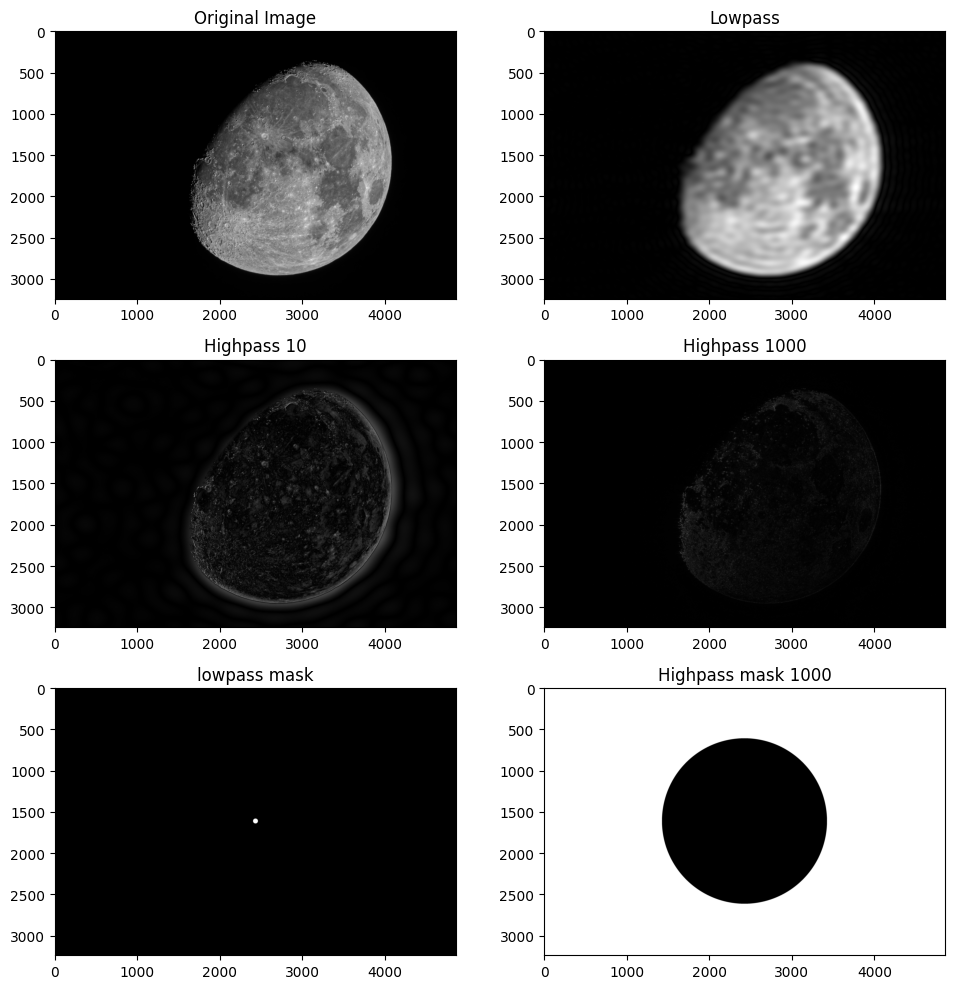

In [13]:
plt.figure(figsize=(10,10))

plt.subplot(3,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(3,2,2)
plt.imshow(img_low_pass, cmap='gray')
plt.title('Lowpass')

plt.subplot(3,2,3)
plt.imshow(img_high_pass30, cmap='gray')
plt.title('Highpass 10')

plt.subplot(3,2,4)
plt.imshow(img_high_pass, cmap='gray')
plt.title('Highpass 1000')

plt.subplot(3,2,6)
plt.imshow(mask_hp, cmap='gray')
plt.title('Highpass mask 1000')

plt.subplot(3,2,5)
plt.imshow(mask_lp, cmap='gray')
plt.title('lowpass mask')

plt.tight_layout()
plt.show()